Exercises:
Conceptual


(1)

Using the basic property of variance for a linear combination of two random variables, $\text{Var}(aX + bY) = a^2 \text{Var}(X) + b^2 \text{Var}(Y) + 2ab \text{Cov}(X,Y)$:

$f(\alpha) = \alpha^2 \text{Var}(X) + (1 - \alpha)^2 \text{Var}(Y) + 2\alpha(1 - \alpha)\text{Cov}(X, Y)$

$\text{Var}(X) = \sigma_X^2$, $\text{Var}(Y) = \sigma_Y^2$, and $\text{Cov}(X,Y) = \sigma_{XY}$:

$f(\alpha) = \alpha^2 \sigma_X^2 + (1 - \alpha)^2 \sigma_Y^2 + 2(\alpha - \alpha^2) \sigma_{XY}$


To find the minimum, take the first derivative of $f(\alpha)$ with respect to $\alpha$:

$\frac{df}{d\alpha} = 2\alpha \sigma_X^2 + 2(1 - \alpha)(-1) \sigma_Y^2 + 2(1 - 2\alpha) \sigma_{XY}$



$\frac{df}{d\alpha} = 2\alpha \sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}$


$\frac{df}{d\alpha} = 2 \left[ \alpha \sigma_X^2 - \sigma_Y^2 + \alpha \sigma_Y^2 + \sigma_{XY} - 2\alpha \sigma_{XY} \right]$


$\alpha \sigma_X^2 - \sigma_Y^2 + \alpha \sigma_Y^2 + \sigma_{XY} - 2\alpha \sigma_{XY} = 0$

$\alpha \left(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}\right) - \sigma_Y^2 + \sigma_{XY} = 0$

$\alpha \left(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}\right) = \sigma_Y^2 - \sigma_{XY}$


$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}$


$$\frac{d^2f}{d\alpha^2} = 2(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = 2\text{Var}(X - Y)$$

Since the variance of any non-degenerate random variable is strictly positive ($\text{Var}(X - Y) > 0$), the second derivative is positive, confirming that this value of $\alpha$ indeed **minimizes** the variance.

Exercise 2:

(a)

In a bootstrap sample, $n$ observations are drawn uniformly at random **with replacement** from an original dataset of size $n$.

1. On any single draw, the probability of selecting the $j\text{th}$ observation is $\frac{1}{n}$.
2. By the complement rule, the probability of **not** selecting the $j\text{th}$ observation on the first draw is:

$P(\text{not } j\text{th}) = 1 - \frac{1}{n} = \frac{n - 1}{n}$

(b)

Because bootstrap sampling is performed **with replacement**, each draw is independent and identically distributed. The outcome of the first draw does not alter the probabilities of the second draw.

Thus, the probability that the second bootstrap observation is not the $j\text{th}$ observation is identical to that of the first draw:

$P(\text{2nd draw is not } j\text{th}) = 1 - \frac{1}{n} = \frac{n - 1}{n}$

(c)

A bootstrap sample takes $n$ total independent draws. For observation $j$ to be completely left out, it must be missed on every single draw:


$P(\text{not in sample}) = {\left(1 - \frac{1}{n}\right) \times \left(1 - \frac{1}{n}\right)\dots \times \left(1 - \frac{1}{n}\right)}_{n \text{ times}} = \left(1 - \frac{1}{n}\right)^n$

(d)

Using the complement rule along with the result from part (c):

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 5$:

$P = 1 - \left(1 - \frac{1}{5}\right)^5 = 1 - \left(\frac{4}{5}\right)^5 = 1 - 0.32768 = 0.67232$

There is a **67.23%** chance that the $j\text{th}$ observation is included in the bootstrap sample.

(e)

Using the complement rule:

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 100$:

$P = 1 - \left(1 - \frac{1}{100}\right)^{100} = 1 - (0.99)^{100} \approx 1 - 0.36603 = 0.63397$

There is a **63.40%** chance that the $j\text{th}$ observation is included in the bootstrap sample.

(f)

Using the complement rule:

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 10000$:

$$P = 1 - \left(1 - \frac{1}{10000}\right)^{10000} = 1 - (0.9999)^{10000} \approx 1 - 0.36786 = 0.63214$$

There is a **63.21%** chance that the $j\text{th}$ observation is included in the bootstrap sample.


(g)

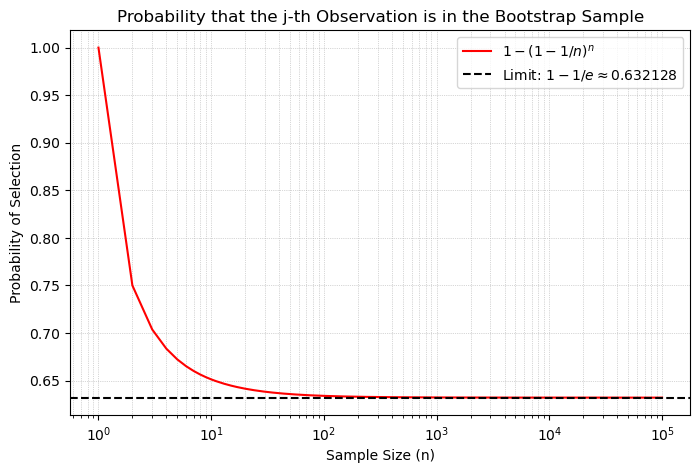

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_values = np.arange(1, 100001)

probabilities = 1 - (1 - 1 / n_values) ** n_values

plt.figure(figsize=(8, 5))
plt.plot(n_values, probabilities, label=r"$1 - (1 - 1/n)^n$", color="red")
plt.axhline(y=1 - 1 / np.e, color="black", linestyle="--", label=r"Limit: $1 - 1/e \approx 0.632128$")
plt.xscale("log") 
plt.xlabel("Sample Size (n)")
plt.ylabel("Probability of Selection")
plt.title("Probability that the j-th Observation is in the Bootstrap Sample")
plt.legend()
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.show()

In [10]:
#(h)
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0

print(np.mean(store))

0.6362


The simulation result closely matches the theoretical probability of 0.6340 (63.40%) derived in part (e), empirically confirming our theoretical derivation.

Exercise 3:

(a):

First, it splits dataset randomly into $K$ equal groups (folds).

Next, pick one fold to serve as the validation set, and train your model on the remaining $K-1$ folds. Calculate the prediction error on that test fold.

Repeat this process $K$ times so every fold acts as the test set exactly once. Finally, average the $K$ error scores to get your overall test error estimate.


(b) Advantages and Disadvantages

- the Validation Set Approach

**Advantages:** It uses more data for training (e.g., 90% for $K=10$ versus 50%), which reduces bias and avoids overestimating test error. It also averages results across multiple folds, giving a much more stable estimate that depends less on a single random split.

**Disadvantage:** It takes $K$ times longer to compute because you must fit the model $K$ times instead of just once.

- LOOCV ($K = n$)

**Advantages:** It is drastically faster to run because fitting $5$ or $10$ models requires far less computation than fitting $n$ models. It also has lower overall variance: LOOCV models train on almost identical datasets, making their outputs heavily correlated, which inflates the variance of the average score.

**Disadvantage:** It has slightly higher bias because each training set leaves out a larger portion of data compared to LOOCV's $n-1$ observations.

Exercise 4

We estimate the standard deviation (standard error) of our prediction $\hat{Y}_0$ at a specific point $X_0$ using the **bootstrap method**:

1. **Resample:** Generate $B$ bootstrap datasets by sampling $n$ observations from the original data with replacement.
2. **Fit Models:** Fit the statistical learning model on each bootstrap sample $b \in \{1, 2, \dots, B\}$.
3. **Predict:** Obtain the predicted response $\hat{Y}_0^{*b}$ at $X = X_0$ for each fitted model.
4. **Compute Standard Deviation:** Calculate the standard error of these predictions:

$$\text{SE}(\hat{Y}_0) = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B} \left(\hat{Y}_0^{*b} - \bar{\hat{Y}}_0\right)^2}$$



where $\bar{\hat{Y}}_0 = \frac{1}{B}\sum_{b=1}^{B} \hat{Y}_0^{*b}$.